# Tomato Disease Classification
Dataset credits: https://www.kaggle.com/arjuntejaswi/plant-village

### Import all the Dependencies

In [13]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

### Set all the Constants

Tomato has 10 classes so we set `N_CLASSES = 10`.
Everything else (image size, batch size) stays the same as our potato model.

In [34]:
BATCH_SIZE = 8        # reduced from 32
IMAGE_SIZE = 128       # reduced from 256
CHANNELS = 3
EPOCHS = 50
N_CLASSES = 10

### Import data into tensorflow dataset object

Make sure your folder structure looks like this:
```
TomatoVillage/
    Tomato_Bacterial_spot/
    Tomato_Early_blight/
    Tomato_Late_blight/
    Tomato_Leaf_Mold/
    Tomato_Septoria_leaf_spot/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato__Target_Spot/
    Tomato__Tomato_YellowLeaf__Curl_Virus/
    Tomato__Tomato_mosaic_virus/
    Tomato_healthy/
```
You can get this from the PlantVillage dataset on Kaggle.
Just copy the 10 tomato folders into a single `TomatoVillage` directory.

In [35]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "TomatoVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 16011 files belonging to 10 classes.


In [36]:
class_names = dataset.class_names
print(f"Found {len(class_names)} classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Found 10 classes:
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy


In [37]:
for image_batch, labels_batch in dataset.take(1):
    print("Image batch shape :", image_batch.shape)
    print("Labels batch shape:", labels_batch.numpy())

Image batch shape : (8, 128, 128, 3)
Labels batch shape: [7 2 4 6 5 7 7 5]


### Visualize some images from the dataset

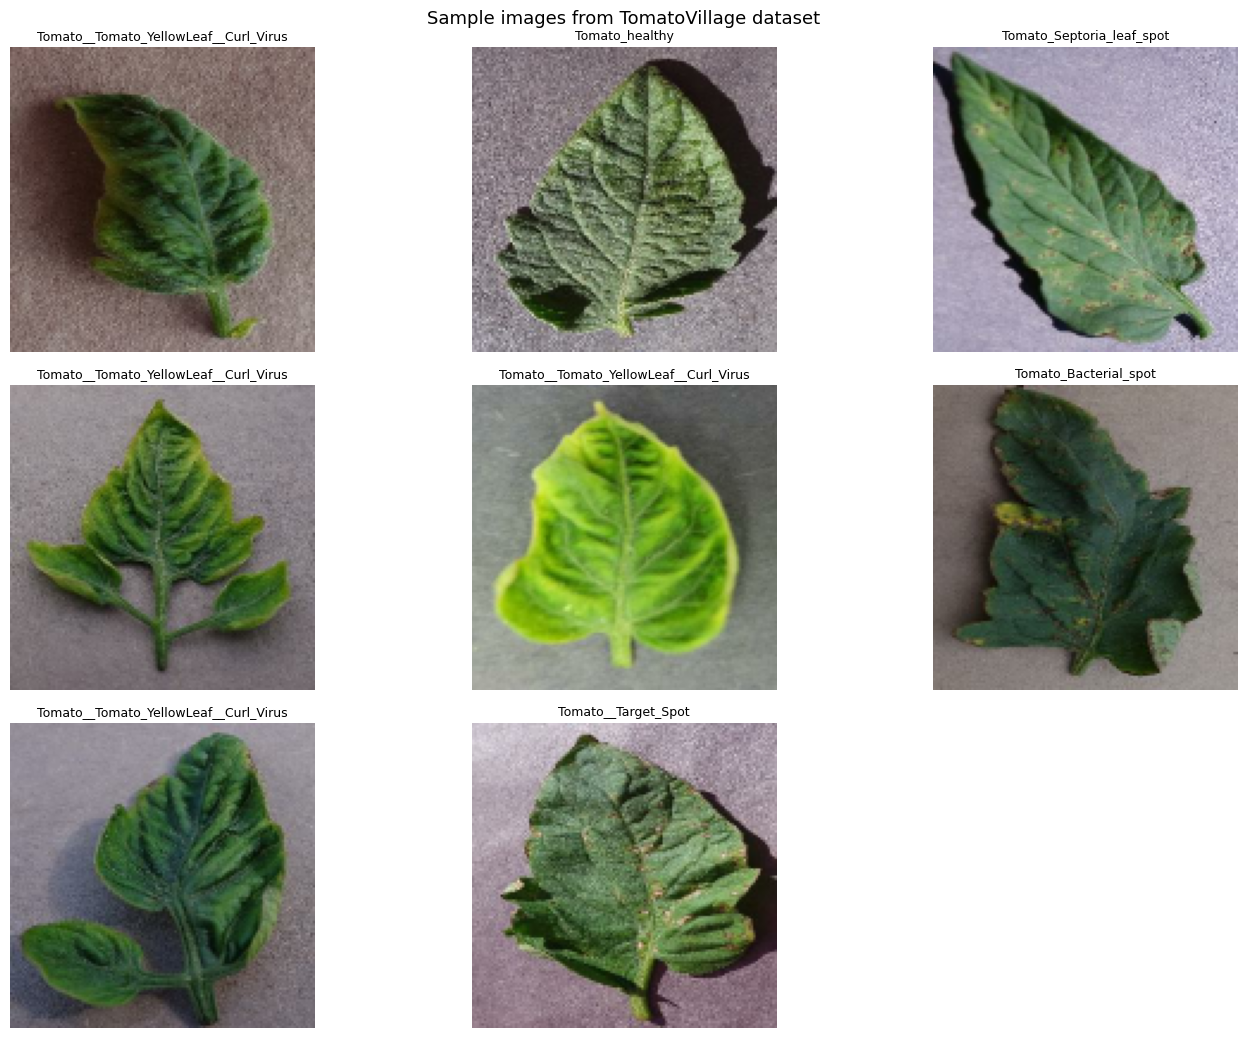

In [38]:
plt.figure(figsize=(14, 14))
for image_batch, label_batch in dataset.take(1):
    num_images = min(12, len(image_batch))  # don't exceed actual batch size
    for i in range(num_images):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample images from TomatoVillage dataset", fontsize=13)
plt.tight_layout()
plt.show()

### Split dataset into Train, Validation, and Test sets

We use the same 80/10/10 split strategy as our potato model.

In [39]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size   = int(val_split   * ds_size)

    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [40]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print(f"Train batches      : {len(train_ds)}")
print(f"Validation batches : {len(val_ds)}")
print(f"Test batches       : {len(test_ds)}")

Train batches      : 1601
Validation batches : 200
Test batches       : 201


### Cache, Shuffle, and Prefetch the Dataset

This speeds up training by preparing batches in the background while the GPU is busy.

In [41]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

### Creating a Layer for Resizing and Normalization

We normalize pixel values to [0, 1] by dividing by 255.
This layer is baked into the model so it also runs at inference time.

In [42]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0 / 255),
])

### Data Augmentation

Tomato has 10 classes with more images per class, so augmentation is still helpful
to prevent overfitting. We use the same flips and rotations as the potato model.

In [43]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

In [44]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

### Model Architecture

We use the same CNN architecture as the potato model.
The **only change** is the final Dense layer output: `N_CLASSES = 10` instead of 3,
because tomato has 10 disease classes.

In [45]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
])

model.build(input_shape=input_shape)
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (8, 128, 128, 3)          0         
                                                                 
 sequential_5 (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 conv2d_10 (Conv2D)          (8, 126, 126, 32)         896       
                                                                 
 max_pooling2d_10 (MaxPooli  (8, 63, 63, 32)           0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (8, 61, 61, 64)           18496     
                                                                 
 max_pooling2d_11 (MaxPooli  (8, 30, 30, 64)           0         
 ng2D)                                                

### Compile the Model

In [46]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the Model

We add **EarlyStopping** here (not in the potato notebook).
It watches `val_loss` and stops training automatically if the model stops improving.
`restore_best_weights=True` means it saves the best version of the model automatically.

This prevents overfitting and saves time — you don't have to wait all 50 epochs.

In [47]:
import os
classes = sorted(os.listdir("TomatoVillage"))
print(f"Total folders found: {len(classes)}")
for i, c in enumerate(classes):
    print(f"  {i}: {c}")

Total folders found: 10
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,              # stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=10,
    callbacks=[early_stopping]
)

### Evaluate on Test Set

In [ ]:
scores = model.evaluate(test_ds)
print(f"\nTest Loss     : {scores[0]:.4f}")
print(f"Test Accuracy : {scores[1]*100:.2f}%")

### Plot Training & Validation Accuracy / Loss

These plots show if the model is overfitting. 
If train accuracy is much higher than val accuracy, that means overfitting.

In [ ]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_ran = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, acc,     label='Training Accuracy')
plt.plot(epochs_ran, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, loss,     label='Training Loss')
plt.plot(epochs_ran, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

### Confusion Matrix

A confusion matrix shows exactly which classes the model confuses with each other.
This is a very important chart to show during your project viva — it proves you understand
your model's weaknesses, not just its overall accuracy.

In [ ]:
# Collect all true labels and predicted labels from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Short display names for the 10 classes
short_names = [
    "Bacterial Spot",
    "Early Blight",
    "Late Blight",
    "Leaf Mold",
    "Septoria Spot",
    "Spider Mites",
    "Target Spot",
    "YL Curl Virus",
    "Mosaic Virus",
    "Healthy"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=short_names,
    yticklabels=short_names
)
plt.title('Confusion Matrix — Tomato Disease Classification', fontsize=13)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Classification Report

Shows precision, recall, and F1-score for each class individually.
Great to include in your project report.

In [ ]:
print(classification_report(y_true, y_pred, target_names=short_names))

### Run predictions on sample test images

In [ ]:
def predict(model, img):
    img_array  = tf.keras.preprocessing.image.img_to_array(img)
    img_array  = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        color = 'green' if predicted_class == actual_class else 'red'
        plt.title(
            f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%",
            color=color,
            fontsize=8
        )
        plt.axis("off")
plt.tight_layout()
plt.show()

### Saving the Model

We save to `saved_models/tomato/1` so the FastAPI backend can load it.
This matches the path in `main.py`: `saved_models/tomato/1`

In [ ]:
import os

save_dir = "../saved_models/tomato"
os.makedirs(save_dir, exist_ok=True)

# Version the model the same way as the potato notebook
existing = [int(i) for i in os.listdir(save_dir) if i.isdigit()]
model_version = max(existing + [0]) + 1

save_path = f"{save_dir}/{model_version}"
model.save(save_path)
print(f"Model saved to: {save_path}")

In [ ]:
# Also save as .h5 for backup (same as potato notebook saves potatoes.h5)
model.save("../tomatoes.h5")
print("Backup saved to: ../tomatoes.h5")